In [1]:
import pandas as pd

url = "https://zenodo.org/records/7395559/files/creditcard.csv?download=1"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())


Dataset loaded successfully!
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:



print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nFraud vs genuine transactions:")
print(df["Class"].value_counts())


Dataset shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
0

Fraud vs genuine transactions:
Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
# Check the target column
print("Original dataset shape:", df.shape)

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Data preparation completed!")




Original dataset shape: (284807, 31)
Training data: (227845, 30)
Testing data: (56962, 30)
Data preparation completed!


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed!")

# Model 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")




Logistic Regression training completed!
Random Forest training completed!


In [5]:



# Make predictions on the test data
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

print("Logistic Regression predictions completed!")
print("Random Forest predictions completed!")

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].tolist())

print("\nFirst 10 Logistic Regression predictions:")
print(lr_pred[:10].tolist())

print("\nFirst 10 Random Forest predictions:")
print(rf_pred[:10].tolist())


Logistic Regression predictions completed!
Random Forest predictions completed!

First 10 actual labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

First 10 Logistic Regression predictions:
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

First 10 Random Forest predictions:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Evaluate Logistic Regression
print("LOGISTIC REGRESSION REPORT")
print(classification_report(y_test, lr_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

# Evaluate Random Forest
print("\nRANDOM FOREST REPORT")
print(classification_report(y_test, rf_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))




LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Confusion Matrix:
[[55478  1386]
 [    8    90]]

RANDOM FOREST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56861     3]
 [   25    73]]


In [7]:
results = []

models = {
    "Logistic Regression": (y_test, lr_pred),
    "Random Forest": (y_test, rf_pred)
}

for name, (actual, predicted) in models.items():
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(actual, predicted), 4),
        "Precision": round(precision_score(
            actual, predicted, zero_division=0
        ), 4),
        "Recall": round(recall_score(
            actual, predicted, zero_division=0
        ), 4),
        "F1 Score": round(f1_score(
            actual, predicted, zero_division=0
        ), 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

print("Model comparison completed!")




,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9755,0.0610,0.9184,0.1144
1,Random Forest,0.9995,0.9605,0.7449,0.8391


Model comparison completed!


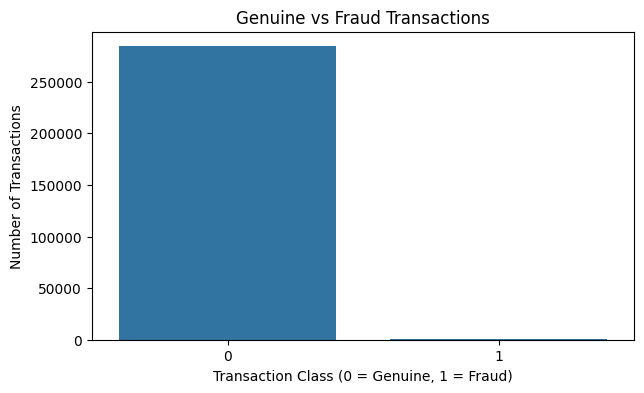

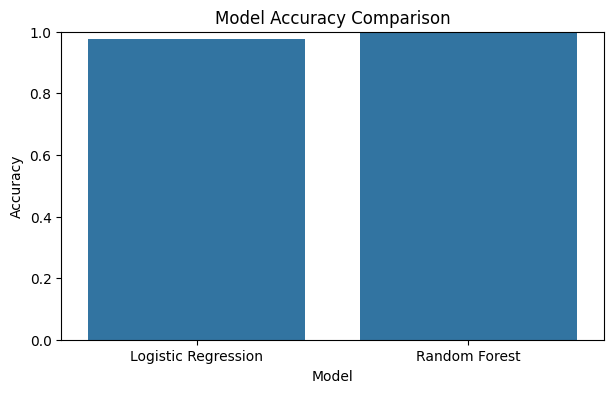

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph 1: Genuine vs Fraud transactions
plt.figure(figsize=(7, 4))
sns.countplot(x="Class", data=df)
plt.title("Genuine vs Fraud Transactions")
plt.xlabel("Transaction Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

# Graph 2: Model Accuracy Comparison
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.show()


In [9]:
# Find the model with the highest F1 score
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("=" * 45)
print("CREDIT CARD FRAUD DETECTION")
print("PROJECT CONCLUSION")
print("=" * 45)

print("\nModel Comparison:")
display(results_df)

print("\nBest Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])

print("\nConclusion:")
print("This project uses machine learning to identify potentially fraudulent credit card transactions.")
print("Logistic Regression and Random Forest models were trained and evaluated.")
print("The models were compared using accuracy, precision, recall, and F1 score.")
print("Fraud detection requires careful evaluation because fraudulent transactions are rare.")
print("This project demonstrates how machine learning can support fraud detection.")

print("\nProject completed!")

CREDIT CARD FRAUD DETECTION
PROJECT CONCLUSION

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9755,0.0610,0.9184,0.1144
1,Random Forest,0.9995,0.9605,0.7449,0.8391



Best Model: Random Forest
Accuracy: 0.9995
Precision: 0.9605
Recall: 0.7449
F1 Score: 0.8391

Conclusion:
This project uses machine learning to identify potentially fraudulent credit card transactions.
Logistic Regression and Random Forest models were trained and evaluated.
The models were compared using accuracy, precision, recall, and F1 score.
Fraud detection requires careful evaluation because fraudulent transactions are rare.
This project demonstrates how machine learning can support fraud detection.

Project completed!
